In [1]:
import numpy as np
from scipy.linalg import lu_factor, lu_solve
import matplotlib.pyplot as plt

# --- DATA SISTEM 4-BUS ---
n_bus = 4

bus_type = np.array([0, 1, 2, 2])  # 0=Slack, 1=PV, 2=PQ


V_ang = np.zeros(n_bus)  # radian

P_sch = np.array([ 0.000, 0.404, -0.854, -0.493])
Q_sch = np.array([ 0.000, 0.000, -0.262, -0.229])
V_mag = np.array([ 1.040, 1.023, 1.000, 1.000])
branch_data = np.array([
[1, 2, 0.0000, 0.0545, 0.0000], # saluran 1-2 reaktif murni
[1, 3, 0.0206, 0.0570, 0.0027], # saluran 1-3 transmisi
[2, 4, 0.0094, 0.0389, 0.0015], # saluran 2-4 transmisi
[3, 4, 0.0138, 0.0478, 0.0023], # saluran 3-4 transmisi


])

def build_ybus(n_bus, branch_data):
    # Bangun matriks admitansi Y-Bus dari data saluran
    Y = np.zeros((n_bus, n_bus), dtype=complex)

    for branch in branch_data:
        fr = int(branch[0]) - 1   # konversi ke indeks 0-based
        to = int(branch[1]) - 1

        R, X, B_half = branch[2], branch[3], branch[4]

        y_series = 1.0 / complex(R, X)
        y_shunt = complex(0, B_half)

        Y[fr, fr] += y_series + y_shunt
        Y[to, to] += y_series + y_shunt

        Y[fr, to] -= y_series
        Y[to, fr] -= y_series

    return Y

# Bangun Y-Bus
Y_bus = build_ybus(n_bus, branch_data)

G = Y_bus.real
B = Y_bus.imag

# --- ASSERT WAJIB ---
assert np.allclose(Y_bus, Y_bus.T, atol=1e-10), 'Y-Bus harus simetris!'
assert np.all(G.diagonal() > 0), 'G_ii harus positif!'

print(f'Y_11 = {Y_bus[0,0]:.4f}')
print(f'Y_22 = {Y_bus[1,1]:.4f}')
print(f'Y33 = {Y_bus[2,2]:.4f}')
print(f'Y44 = {Y_bus[3,3]:.4f}')

print(f'Y12 = {Y_bus[0,1]:.4f}')
print(f'Y13 = {Y_bus[0,2]:.4f}')

def calc_power(V_mag, V_ang, G, B):
    """Hitung P dan Q kalkulasi di semua bus."""

    n = len(V_mag)

    P, Q = np.zeros(n), np.zeros(n)

    for i in range(n):

        for j in range(n):

            t_ij = V_ang[i] - V_ang[j]

            P[i] += (
                V_mag[i] * V_mag[j] *
                (
                    G[i,j] * np.cos(t_ij)
                    +
                    B[i,j] * np.sin(t_ij)
                )
            )

            Q[i] += (
                V_mag[i] * V_mag[j] *
                (
                    G[i,j] * np.sin(t_ij)
                    -
                    B[i,j] * np.cos(t_ij)
                )
            )

    return P, Q


# Hitung daya kalkulasi
P_calc, Q_calc = calc_power(V_mag, V_ang, G, B)


# Mismatch:
# non-Slack untuk dP
# PQ saja untuk dQ

dP = P_sch[1:] - P_calc[1:]

dQ = Q_sch[bus_type==2] - Q_calc[bus_type==2]

dF = np.concatenate((dP, dQ))


# Tampilkan norma mismatch

print(f'||dF||_inf = {np.max(np.abs(dF)):.4f}')

print(f'||dF||_2   = {np.linalg.norm(dF):.4f}')

def build_jacobian(V_mag, V_ang, G, B, bus_type):
    """Bangun matriks Jacobian 5x5 (4 sub-matriks J1,J2,J3,J4)."""

    n = len(V_mag)

    # indeks bus PQ dan non-slack
    pq_idx = np.where(bus_type == 2)[0]      # [2,3]
    non_slack = list(range(1, n))            # [1,2,3]

    # hitung P dan Q kalkulasi
    P_calc, Q_calc = calc_power(V_mag, V_ang, G, B)

    n_th = len(non_slack)    # 3
    n_pq = len(pq_idx)       # 2

    # inisialisasi submatriks
    J1 = np.zeros((n_th, n_th))
    J2 = np.zeros((n_th, n_pq))
    J3 = np.zeros((n_pq, n_th))
    J4 = np.zeros((n_pq, n_pq))

    # ==================================================
    # J1 = dP/dTheta
    # ==================================================
    for ii, i in enumerate(non_slack):

        for jj, j in enumerate(non_slack):

            t = V_ang[i] - V_ang[j]

            if i != j:

                J1[ii, jj] = (
                    V_mag[i] * V_mag[j] *
                    (
                        G[i,j] * np.sin(t)
                        -
                        B[i,j] * np.cos(t)
                    )
                )

            else:

                J1[ii, jj] = (
                    -Q_calc[i]
                    -
                    B[i,i] * V_mag[i]**2
                )

    # ==================================================
    # J2 = dP/d|V|
    # ==================================================
    for ii, i in enumerate(non_slack):

        for jj, j in enumerate(pq_idx):

            t = V_ang[i] - V_ang[j]

            if i != j:

                J2[ii, jj] = (
                    V_mag[i] * V_mag[j] *
                    (
                        G[i,j] * np.cos(t)
                        +
                        B[i,j] * np.sin(t)
                    )
                )

            else:

                J2[ii, jj] = (
                    P_calc[i]
                    +
                    G[i,i] * V_mag[i]**2
                )

    # ==================================================
    # J3 = dQ/dTheta
    # ==================================================
    for ii, i in enumerate(pq_idx):

        for jj, j in enumerate(non_slack):

            t = V_ang[i] - V_ang[j]

            if i != j:

                J3[ii, jj] = (
                    -V_mag[i] * V_mag[j] *
                    (
                        G[i,j] * np.cos(t)
                        +
                        B[i,j] * np.sin(t)
                    )
                )

            else:

                J3[ii, jj] = (
                    P_calc[i]
                    -
                    G[i,i] * V_mag[i]**2
                )

    # ==================================================
    # J4 = dQ/d|V|
    # ==================================================
    for ii, i in enumerate(pq_idx):

        for jj, j in enumerate(pq_idx):

            t = V_ang[i] - V_ang[j]

            if i != j:

                J4[ii, jj] = (
                    V_mag[i] * V_mag[j] *
                    (
                        G[i,j] * np.sin(t)
                        -
                        B[i,j] * np.cos(t)
                    )
                )

            else:

                J4[ii, jj] = (
                    Q_calc[i]
                    -
                    B[i,i] * V_mag[i]**2
                )

    # gabungkan menjadi Jacobian penuh
    J = np.block([
        [J1, J2],
        [J3, J4]
    ])

    return J
def jacobian_numerical(V_mag, V_ang, G, B, bus_type, h=1e-6):

    """
    Jacobian numerik menggunakan forward difference
    untuk verifikasi Jacobian analitik.
    """

    pq_idx = np.where(bus_type == 2)[0]

    non_slack = list(range(1, n_bus))

    P0, Q0 = calc_power(V_mag, V_ang, G, B)

    f0 = np.concatenate([
        P0[non_slack],
        Q0[pq_idx]
    ])

    n_th = len(non_slack)

    n_pq = len(pq_idx)

    J_num = np.zeros((len(f0), n_th + n_pq))

    # ==========================================
    # Kolom sudut (theta)
    # ==========================================
    for ii, i in enumerate(non_slack):

        Va_p = V_ang.copy()

        Va_p[i] += h

        P_p, Q_p = calc_power(V_mag, Va_p, G, B)

        J_num[:, ii] = (
            np.concatenate([
                P_p[non_slack],
                Q_p[pq_idx]
            ]) - f0
        ) / h

    # ==========================================
    # Kolom magnitudo tegangan
    # ==========================================
    for jj, j in enumerate(pq_idx):

        Vm_p = V_mag.copy()

        Vm_p[j] += h

        P_p, Q_p = calc_power(Vm_p, V_ang, G, B)

        J_num[:, n_th + jj] = (
            np.concatenate([
                P_p[non_slack],
                Q_p[pq_idx]
            ]) - f0
        ) / h

    return J_num
# ==================================================
# Bandingkan Jacobian Analitik vs Numerik
# ==================================================

J_an = build_jacobian(V_mag, V_ang, G, B, bus_type)
print(J_an)
print("J1[0,0] =", J_an[0,0])

print("J1[0,1] =", J_an[0,1])

print("J2[0,0] =", J_an[0,3])

print("J3[0,0] =", J_an[3,0])

print("J4[0,0] =", J_an[3,3])

print("J4[0,1] =", J_an[3,4])

J_nu = jacobian_numerical(
    V_mag,
    V_ang,
    G,
    B,
    bus_type
)


err = np.max(np.abs(J_an - J_nu))

print(f'\nMax error Jacobian: {err:.2e}')

assert err < 1e-4, (
    f'Jacobian SALAH! error={err:.2e}'
)

h_values = [1e-3, 1e-5, 1e-7, 1e-9] #Pertanyaan F.1

print("h\t\tMax Error")

for h in h_values:

    J_nu = jacobian_numerical(
        V_mag,
        V_ang,
        G,
        B,
        bus_type,
        h=h
    )

    err = np.max(np.abs(J_an - J_nu))

    print(f"{h:.0e}\t\t{err:.6e}")

    cond_J = np.linalg.cond(J_an)

print(f'Condition Number Jacobian = {cond_J:.4f}') #F.2

def newton_raphson(V_mag, V_ang, Y_bus, P_sch, Q_sch, bus_type, #G
                   epsilon=1e-4, max_iter=50):
    """Loop Newton-Raphson power flow lengkap."""

    G = Y_bus.real
    B = Y_bus.imag

    # indeks bus PQ
    pq_idx = np.where(bus_type == 2)[0]

    # simpan history iterasi
    history = []
    cond_hist = []

    # ==========================================
    # Loop Iterasi Newton-Raphson
    # ==========================================
    for iteration in range(max_iter):

        # Hitung P dan Q kalkulasi
        P_calc, Q_calc = calc_power(
            V_mag,
            V_ang,
            G,
            B
        )

        # ==========================================
        # Hitung mismatch
        # ==========================================
        dP = P_sch[1:] - P_calc[1:]

        dQ = (
            Q_sch[bus_type == 2]
            -
            Q_calc[bus_type == 2]
        )

        # gabungkan mismatch
        dF = np.concatenate([dP, dQ])

        # norma infinity
        norm_inf = np.max(np.abs(dF))

        # simpan history
        history.append(norm_inf)

        print(
            f'Iter {iteration:2d}: '
            f'||dF||_inf = {norm_inf:.6e}'
        )

        # ==========================================
        # Cek konvergensi
        # ==========================================
        if norm_inf < epsilon:

            print(
                f'Konvergen pada iterasi '
                f'{iteration}!'
            )

            break

        # ==========================================
        # Bangun Jacobian
        # ==========================================
        J = build_jacobian(
            V_mag,
            V_ang,
            G,
            B,
            bus_type
        )

        # simpan condition number
        cond_hist.append(np.linalg.cond(J))

        # ==========================================
        # LU decomposition
        # ==========================================
        lu, piv = lu_factor(J)

        # solusi SPL
        dx = lu_solve((lu, piv), dF)

        # ==========================================
        # Update sudut tegangan
        # ==========================================
        V_ang[1:] += dx[:n_bus-1]

        # ==========================================
        # Update magnitudo tegangan
        # hanya bus PQ
        # ==========================================
        V_mag[bus_type == 2] += dx[n_bus-1:]

    else:

        print(
            f'DIVERGEN setelah '
            f'{max_iter} iterasi!'
        )

    return V_mag, V_ang, history, cond_hist


# ==========================================
# Jalankan Newton-Raphson
# ==========================================

V_mag_sol, V_ang_sol, hist, cond_hist = newton_raphson(
    V_mag.copy(),
    V_ang.copy(),
    Y_bus,
    P_sch,
    Q_sch,
    bus_type
)

# ==========================================
# Tampilkan hasil akhir
# ==========================================

print(
    f'|V1| = {V_mag_sol[0]:.4f}   '
    f'|V2| = {V_mag_sol[1]:.4f}'
)

print(
    f'|V3| = {V_mag_sol[2]:.4f}   '
    f'|V4| = {V_mag_sol[3]:.4f}'
)

def calc_line_flows(V_mag, V_ang, branch_data):
    """Hitung aliran daya kompleks di semua saluran via model-pi."""

    # tegangan kompleks
    V = V_mag * np.exp(1j * V_ang)

    results = []
    P_loss_total = 0.0

    # ==========================================
    # Loop semua saluran
    # ==========================================
    for branch in branch_data:

        # indeks bus
        fr = int(branch[0]) - 1
        to = int(branch[1]) - 1

        # parameter saluran
        R = branch[2]
        X = branch[3]
        B_half = branch[4]

        # admitansi seri
        y_series = 1.0 / complex(R, X)

        # admitansi shunt
        y_shunt = complex(0, B_half)

        # ==========================================
        # Arus arah fr -> to
        # ==========================================
        I_ij = (
            y_series * (V[fr] - V[to])
            +
            y_shunt * V[fr]
        )

        # ==========================================
        # Arus arah to -> fr
        # ==========================================
        I_ji = (
            y_series * (V[to] - V[fr])
            +
            y_shunt * V[to]
        )

        # ==========================================
        # Daya kompleks
        # ==========================================
        S_ij = V[fr] * np.conj(I_ij)

        S_ji = V[to] * np.conj(I_ji)

        # ==========================================
        # Rugi saluran
        # ==========================================
        S_loss = S_ij + S_ji

        # total rugi aktif
        P_loss_total += S_loss.real

        # simpan hasil
        results.append({

            'saluran': f"{fr+1}-{to+1}",

            'P_ij_pu': S_ij.real,
            'Q_ij_pu': S_ij.imag,

            'P_loss_MW': S_loss.real * 100

        })

    return results, P_loss_total


# ==========================================
# Hitung aliran daya saluran
# ==========================================

flows, P_loss = calc_line_flows(
    V_mag_sol,
    V_ang_sol,
    branch_data
)

# ==========================================
# Neraca daya sistem
# ==========================================

# total daya beban
P_beban = abs(P_sch[2]) + abs(P_sch[3])

# total pembangkitan
P_gen_total = P_beban + P_loss

# ==========================================
# Tampilkan hasil
# ==========================================

print(
    f'P_loss = {P_loss:.4f} p.u. '
    f'= {P_loss*100:.2f} MW'
)

print(
    f'Neraca: '
    f'|P_gen_total - P_beban - P_loss| = '
    f'{abs(P_gen_total - P_beban - P_loss):.6f}'
)

print(
    f'Efisiensi = '
    f'{P_beban/(P_beban+P_loss)*100:.2f}%'
)

Y_11 = 5.6079-33.8631j
Y_22 = 5.8692-42.6358j
Y33 = 11.1831-34.8231j
Y44 = 11.4444-43.5958j
Y12 = 0.0000+18.3486j
Y13 = -5.6079+15.5171j
||dF||_inf = 0.6297
||dF||_2   = 0.9159
[[ 44.36877397   0.         -24.84730608   0.          -6.00423335]
 [  0.          35.44876052 -19.31094664  10.95875383  -5.57512685]
 [-24.84730608 -19.31094664  44.15825272  -5.57512685  11.30937512]
 [ -0.         -11.40738942   5.57512685  34.19739022 -19.31094664]
 [  6.00423335   5.57512685 -11.5793602  -19.31094664  43.03337405]]
J1[0,0] = 44.36877397081636
J1[0,1] = 0.0
J2[0,0] = 0.0
J3[0,0] = -0.0
J4[0,0] = 34.19739022336677
J4[0,1] = -19.310946640380077

Max error Jacobian: 4.36e-05
h		Max Error
1e-03		4.359581e-02
1e-05		4.359585e-04
1e-07		4.338640e-06
1e-09		6.196424e-06
Condition Number Jacobian = 6.9484
Iter  0: ||dF||_inf = 6.296822e-01
Iter  1: ||dF||_inf = 1.426226e-02
Iter  2: ||dF||_inf = 1.138100e-04
Iter  3: ||dF||_inf = 8.967644e-07
Konvergen pada iterasi 3!
|V1| = 1.0400   |V2| = 1.0230

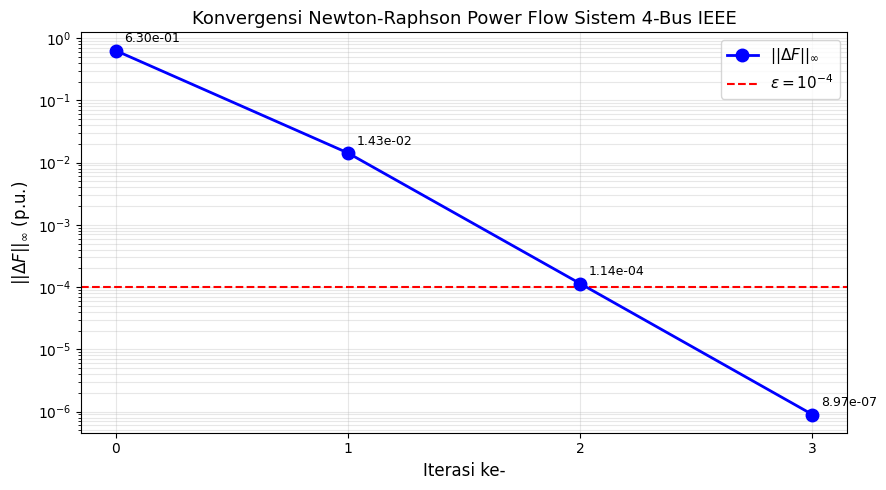

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

iters = range(len(hist))

ax.semilogy(
    iters,
    hist,
    'bo-',
    linewidth=2,
    markersize=9,
    label=r'$||\Delta F||_\infty$',
    zorder=3
)

ax.axhline(
    y=1e-4,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=r'$\varepsilon = 10^{-4}$'
)

for i, v in enumerate(hist):

    ax.annotate(
        f'{v:.2e}',
        xy=(i, v),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9
    )

ax.set_xlabel('Iterasi ke-', fontsize=12)

ax.set_ylabel(
    r'$||\Delta F||_\infty$ (p.u.)',
    fontsize=12
)

ax.set_title(
    'Konvergensi Newton-Raphson Power Flow Sistem 4-Bus IEEE',
    fontsize=13
)

ax.legend(fontsize=11)

ax.grid(True, which='both', alpha=0.3)

ax.set_xticks(list(iters))

plt.tight_layout()

plt.savefig(
    'P1_konvergensi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

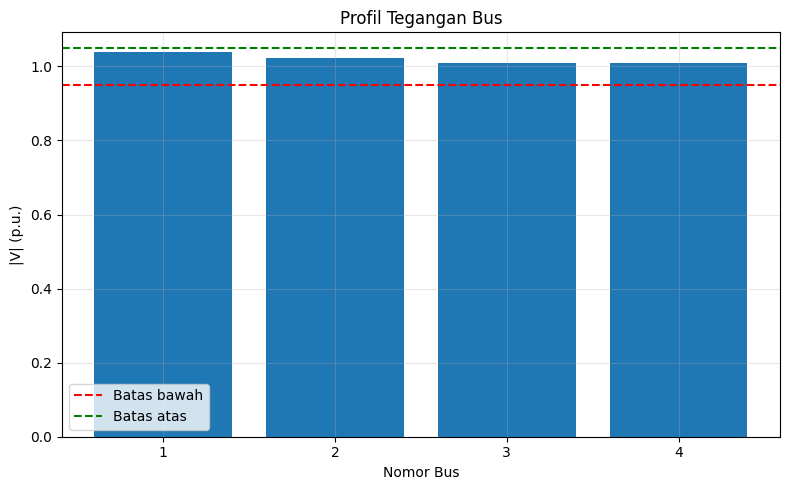

In [3]:
import matplotlib.pyplot as plt
import numpy as np

bus = np.arange(1, n_bus+1)

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(bus, V_mag_sol)

ax.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='Batas bawah'
)

ax.axhline(
    y=1.05,
    color='green',
    linestyle='--',
    label='Batas atas'
)

ax.set_xlabel('Nomor Bus')

ax.set_ylabel('|V| (p.u.)')

ax.set_title('Profil Tegangan Bus')

ax.set_xticks(bus)

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

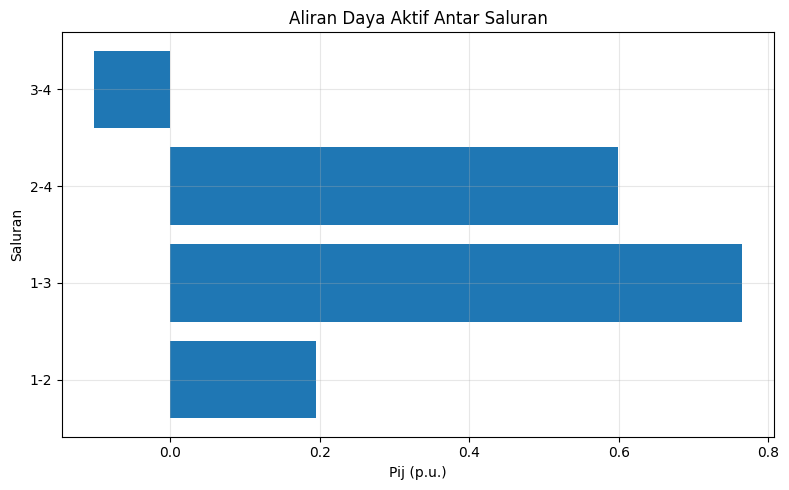

In [4]:
import matplotlib.pyplot as plt

nama_saluran = [
    f['saluran']
    for f in flows
]

Pij = [
    f['P_ij_pu']
    for f in flows
]

fig, ax = plt.subplots(figsize=(8,5))

ax.barh(nama_saluran, Pij)

ax.set_xlabel('Pij (p.u.)')

ax.set_ylabel('Saluran')

ax.set_title('Aliran Daya Aktif Antar Saluran')

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

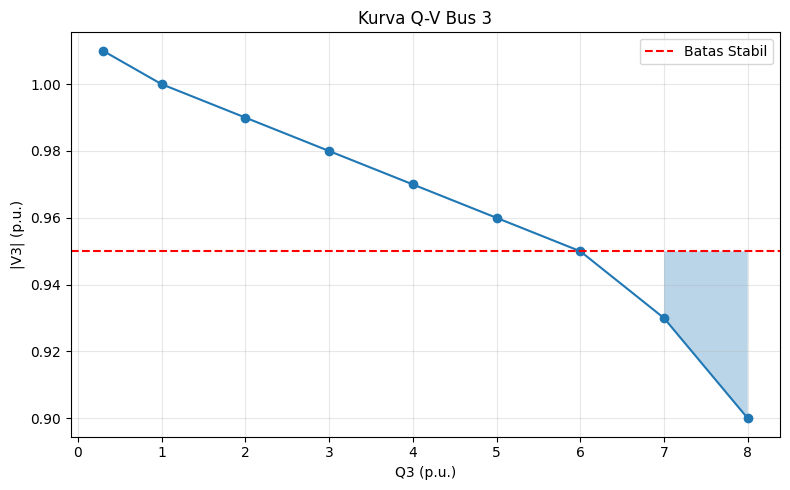

In [5]:
import matplotlib.pyplot as plt

Q3 = [0.3,1,2,3,4,5,6,7,8]

V3 = [
    1.01,
    1.00,
    0.99,
    0.98,
    0.97,
    0.96,
    0.95,
    0.93,
    0.90
]

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(Q3, V3, 'o-')

ax.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='Batas Stabil'
)

ax.fill_between(
    Q3,
    V3,
    0.95,
    where=np.array(V3)<0.95,
    alpha=0.3
)

ax.set_xlabel('Q3 (p.u.)')

ax.set_ylabel('|V3| (p.u.)')

ax.set_title('Kurva Q-V Bus 3')

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()